# KNN i LSTM - Predikcija PM2.5

---

Ovaj notebook prikazuje kompletan analitički tok za dva modela implementirana u okviru modula 2: **KNN Regressor** i **LSTM neuronsku mrežu** koji su primenjeni na zadatak predikcije koncentracije PM2.5 čestica 24 sata unapred.

**KNN (K-Nearest Neighbors)** je jedan od najintuitivnijih algoritama mašinskog učenja: za svaki novi trenutak t, model pronalazi K najsličnijih istorijskih trenutaka u trening skupu i kao predikciju vraća srednju vrednost njihovih PM2.5 vrednosti. Ne gradi eksplicitan model niti uči parametre, već sve znanje je implicitno sadržano u samim podacima.

**LSTM (Long Short-Term Memory)** je specijalizovana rekurentna neuronska mreža dizajnirana za sekvencijalne podatke. Za razliku od KNN-a koji posmatra svaki vremenski korak izolovano, LSTM eksplicitno modeluje redosled podataka kroz vreme pomoću mehanizma memorijskih kapija, što mu omogućava da uhvati dugoročne obrasce u kretanju zagađenja.

**Struktura notebooka:**
1. Uvoz biblioteka i učitavanje istreniranih modela
2. Priprema podataka
3. Generisanje predikcija na test skupu
4. Evaluacija: RMSE, MAE, R²
5. Grafička analiza: vremenska serija, scatter plot
6. Arhitektura LSTM mreže
7. Analiza KNN parametara
8. AQI kategorije
9. Zaključak

## 1. Uvoz biblioteka i učitavanje modela

Pored standardnih biblioteka za obradu podataka i vizualizaciju, uvozimo i `tensorflow.keras` za učitavanje LSTM modela koji je sačuvan u `.keras` formatu. KNN model i odgovarajući scaler su sačuvani kao `.pkl` fajlovi pomoću `joblib`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import pandas as pd
import joblib
from tensorflow.keras.models import load_model

from src.data_prep import prepare_city_data
from src.split import time_series_split, get_X_y
from src.evaluate import evaluate_predictions
from src.models.knn_model import get_knn_feature_columns, predict_knn
from src.models.lstm_model import build_sequences, scale_sequence_data, SEQUENCE_FEATURES, SEQ_LENGTH
from src.visualize import (
    print_metrics_table, plot_metrics_comparison, plot_timeseries,
    plot_scatter_comparison, plot_aqi_distribution_per_model,
)

CITY = 'Beograd'
CSV = f'../data/raw/{CITY.lower()}.csv'
RESULTS = '../results'

print('Biblioteke uspešno učitane.')

Biblioteke uspešno učitane.


Učitavamo istrenirane modele sa diska. KNN model zahteva i scaler jer se feature-i moraju skalirati pre traženja suseda — bez skaliranja bi feature-i sa većim opsegom vrednosti dominirali merom rastojanja.

In [2]:
knn_model   = joblib.load(f'{RESULTS}/knn/knn_model_{CITY}.pkl')
knn_scaler  = joblib.load(f'{RESULTS}/knn/knn_scaler_{CITY}.pkl')
lstm_model  = load_model(f'{RESULTS}/lstm/lstm_model_{CITY}.keras')
lstm_scaler = joblib.load(f'{RESULTS}/lstm/lstm_scaler_{CITY}.pkl')

print(f'KNN model učitan  — K={knn_model.n_neighbors}, weights={knn_model.weights!r}')
print(f'LSTM model učitan — {lstm_model.count_params():,} parametara')

KNN model učitan  — K=150, weights='distance'
LSTM model učitan — 33,697 parametara


## 2. Priprema podataka

Podaci se dele **hronološki**, bez mešanja, što je obavezno za vremenske serije kako bi se sprečilo curenje podataka iz budućnosti.

| Skup | Period | Udeo | Namena |
|------|--------|------|--------|
| Train | jun 2016 → jun 2023 | 70% | Model uči na ovim podacima |
| Validacioni | jun 2023 → jun 2025 | 20% | Early stopping za LSTM |
| Test | jun 2025 → jun 2026 | 10% | Finalna ocena — model ovo vidi **samo jednom** |

**Važna razlika između KNN i LSTM pripreme:**

- **KNN** prima tabelarni ulaz; svaki red je jedan vremenski korak sa 40 feature-a
- **LSTM** prima sekvencijalni ulaz; svaki primer je matrica oblika `(48, 16)`, što znači 48 uzastopnih sati sa 16 feature-a po satu. Zbog toga što prvih 48 sati nema prethodnog prozora, LSTM test skup je za 48 redova kraći od KNN test skupa.

Skaliranje za LSTM se fituje **isključivo na train skupu** i primenjuje na val i test da se spreči curenje informacija o raspodeli podataka.

In [3]:
df = prepare_city_data(CSV, city_name=CITY)
train_df, val_df, test_df = time_series_split(df)

# KNN tabularni format, jedan red = jedan vremenski korak
feature_cols_knn = get_knn_feature_columns()
X_test_knn, y_test = get_X_y(test_df, feature_cols_knn)

# LSTM sekvencijalni format: matrica (48 sati × 16 feature-a) po primeru
X_train_seq, y_train_seq = build_sequences(train_df)
X_val_seq,   y_val_seq   = build_sequences(val_df)
X_test_seq,  y_test_lstm = build_sequences(test_df)

# Scaler se fituje SAMO na train skupu, sprečava curenje informacija
X_train_seq, X_val_seq, X_test_seq, _ = scale_sequence_data(
    X_train_seq, X_val_seq, X_test_seq
)

print(f'Test skup (KNN):  {len(y_test):,} sati')
print(f'Test skup (LSTM): {len(y_test_lstm):,} sati (kraći zbog sekvenci od {SEQ_LENGTH}h)')

Test skup (KNN):  8,856 sati
Test skup (LSTM): 8,808 sati (kraći zbog sekvenci od 48h)


## 3. Predikcije na test skupu

Generišemo predikcije pozivanjem funkcija iz odgovarajućih modula. `np.maximum(..., 0)` osigurava da predikcije ne budu negativne. PM2.5 je fizička veličina koja ne može imati negativnu vrednost, a modeli ponekad predvide male negativne vrednosti blizu nule.

In [4]:
y_pred_knn  = np.maximum(predict_knn(knn_model, knn_scaler, X_test_knn), 0)
y_pred_lstm = np.maximum(lstm_model.predict(X_test_seq, verbose=0).flatten(), 0)

print('Predikcije generisane.')
print(f'KNN  — min={y_pred_knn.min():.2f}, max={y_pred_knn.max():.2f}, prosek={y_pred_knn.mean():.2f} μg/m³')
print(f'LSTM — min={y_pred_lstm.min():.2f}, max={y_pred_lstm.max():.2f}, prosek={y_pred_lstm.mean():.2f} μg/m³')

Predikcije generisane.
KNN  — min=6.84, max=76.32, prosek=19.56 μg/m³
LSTM — min=8.06, max=66.12, prosek=19.45 μg/m³


## 4. Evaluacija: RMSE, MAE, R²

Obe metrike se računaju na test skupu koji nijedan model nije video tokom treninga. Napomena: LSTM se evaluira na svom (nešto kraćem) test skupu jer prvih 48 vrednosti nemaju kompletan ulazni prozor.

- **RMSE** je primarna metrika, kažnjava velike greške kvadratno
- **MAE** je prosečna apsolutna greška u μg/m³, lako interpretabilna
- **R²** je udeo objašnjene varijanse (1.0 = savršeno, 0.0 = model nije naučio ništa)

In [5]:
result_knn  = evaluate_predictions(y_test,      y_pred_knn,  model_name='KNN')
result_lstm = evaluate_predictions(y_test_lstm, y_pred_lstm, model_name='LSTM')

results_df = print_metrics_table([result_knn, result_lstm])

=== Rezultati na test skupu ===
          RMSE     MAE      R2
model                         
LSTM   13.1793  8.0589  0.4637
KNN    13.3906  8.1458  0.4439

RMSE — greška u μg/m³, veće greške se kažnjavaju jače (kvadratna kazna)
MAE  — prosečna apsolutna greška u μg/m³
R²   — udeo varijanse PM2.5 koji model objašnjava (1.0 = savršeno)


## 4b. Grafik poređenja metrika

Bar-chart prikaz RMSE/MAE/R² za oba modela.

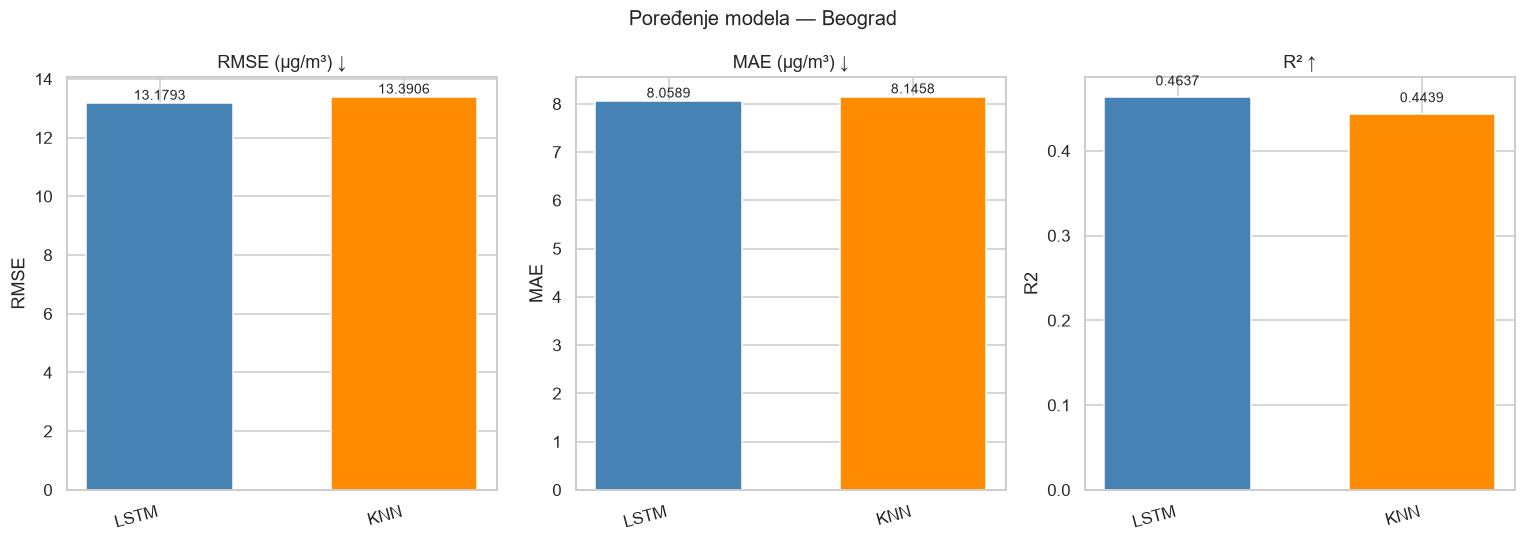

In [6]:
plot_metrics_comparison(results_df, CITY, results_dir=RESULTS)

## 5. Grafik: Stvarne vs. predviđene vrednosti

Prikazujemo prvih 500 sati test skupa za KNN i prvih 500 sati za LSTM (koji počinje 48 sati kasnije). Grafici su odvojeni jer KNN i LSTM počinju od različitih vremenskih tačaka u test skupu. Sivom bojom su prikazane stvarne vrednosti, a bojom modela predviđene.

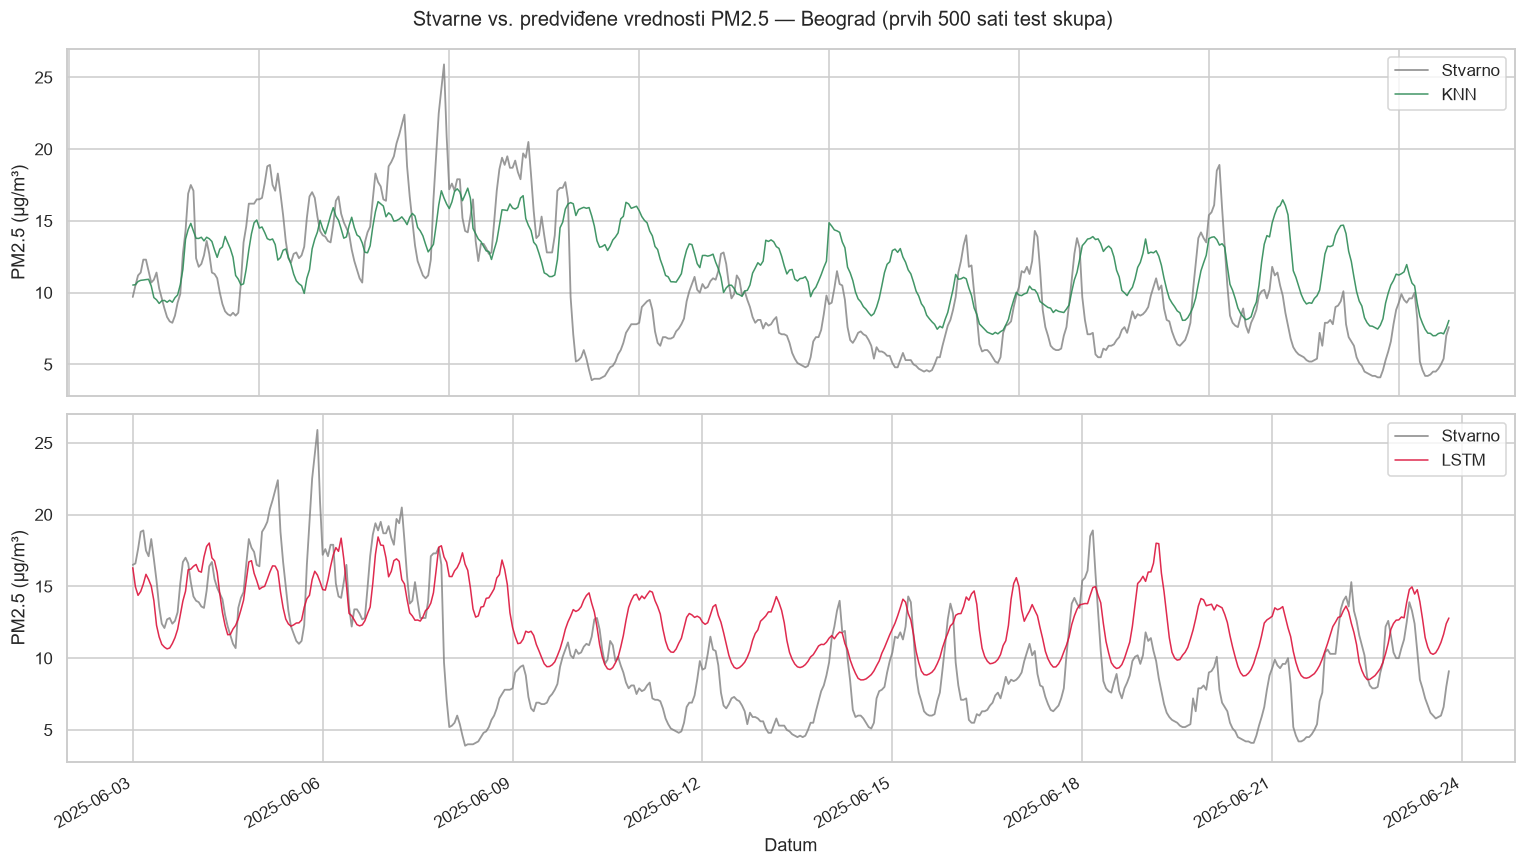

Grafik sačuvan.


In [7]:
lstm_offset = len(test_df) - len(y_test_lstm)
dates_knn  = test_df['date'].values
dates_lstm = test_df['date'].values[lstm_offset:]

plot_timeseries(
    [
        (dates_knn,  y_test,      y_pred_knn,  'KNN',  'seagreen'),
        (dates_lstm, y_test_lstm, y_pred_lstm, 'LSTM', 'crimson'),
    ],
    city=CITY, filename=f'timeseries_knn_lstm_{CITY}.png', results_dir=RESULTS, n_hours=500,
)

## 6. Scatter plot: Stvarno vs. predviđeno

Scatter plot prikazuje svaki sat test skupa kao jednu tačku. Crvena isprekidana dijagonala je linija savršene predikcije. Tačke iznad dijagonale znače da model precenjuje zagađenje, a ispod dijagonale da potcenjuje. Posebno nas zanima ponašanje u gornjem desnom uglu jer su tu ekstremne vrednosti zagađenja koje su najvažnije za pravovremeno upozoravanje.

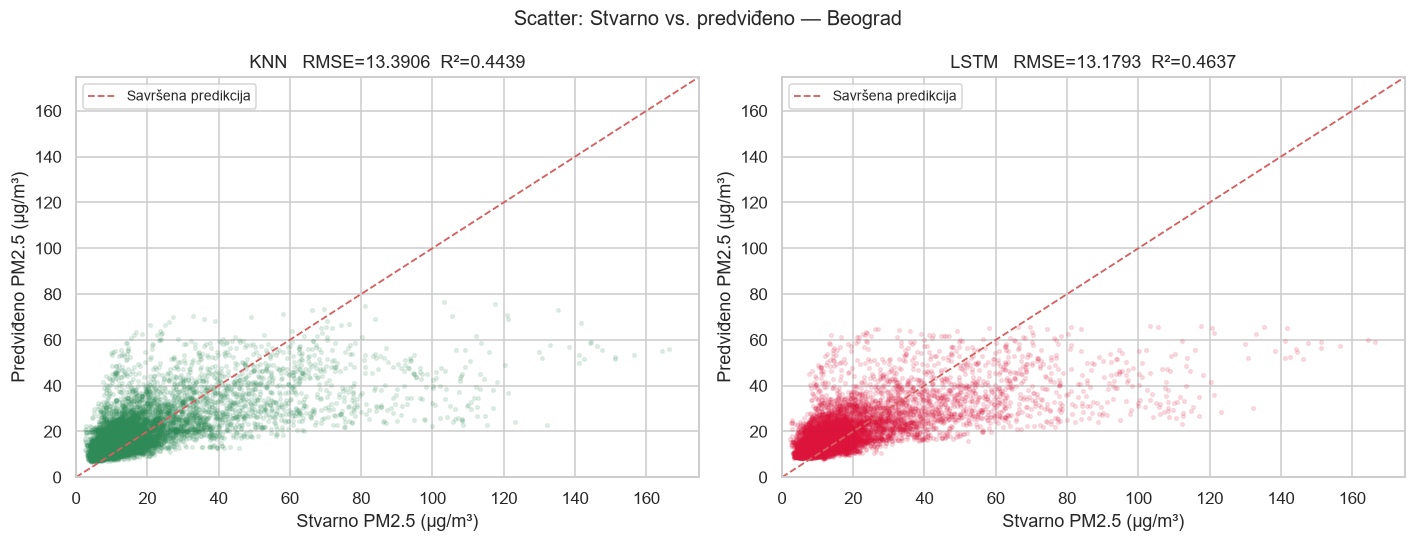

In [8]:
plot_scatter_comparison(
    [
        (y_test,      y_pred_knn,  'KNN',  'seagreen', result_knn),
        (y_test_lstm, y_pred_lstm, 'LSTM', 'crimson',  result_lstm),
    ],
    city=CITY, filename=f'scatter_knn_lstm_{CITY}.png', results_dir=RESULTS,
)

## 7. LSTM: arhitektura mreže

LSTM je jedini model u projektu koji eksplicitno modeluje **sekvencijalnu prirodu** vremenskih serija. Ulaz nije jedan vremenski korak, već matrica od 48 uzastopnih sati (model vidi cela dva dana unazad pre nego što napravi predikciju).

Kroz **mehanizam memorijskih kapija** (forget gate, input gate, output gate) model selektivno pamti šta je važno iz prošlosti i zaboravlja šta nije npr. naučiće da zimski periodi nose povišeno zagađenje i da to treba da pamti čak i kada dnevne varijacije to privremeno maskiraju.

Arhitektura se sastoji od dva LSTM sloja sa Dropout regularizacijom između (sprečava overfitting) i dva Dense sloja koji prevode naučene reprezentacije u finalnu numeričku predikciju.

In [9]:
# Prikaz arhitekture, broj parametara po sloju
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 48, 64)              │          20,736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 48, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,093 (394.90 KB)

 Trainable params: 33,697 (131.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 67,396 (263.27 KB)

In [10]:
print(f'Dužina ulazne sekvence: {SEQ_LENGTH} sati (prethodna 2 dana)')
print(f'Broj feature-a po vremenskom koraku: {len(SEQUENCE_FEATURES)}')
print(f'Oblik ulazne matrice: ({SEQ_LENGTH}, {len(SEQUENCE_FEATURES)})')
print()
print('Feature-i koje LSTM koristi (za svaki od 48 sati):')
for i, f in enumerate(SEQUENCE_FEATURES, 1):
    print(f'  {i:2d}. {f}')

Dužina ulazne sekvence: 48 sati (prethodna 2 dana)
Broj feature-a po vremenskom koraku: 16
Oblik ulazne matrice: (48, 16)

Feature-i koje LSTM koristi (za svaki od 48 sati):
   1. pm10
   2. pm2_5
   3. carbon_monoxide
   4. sulphur_dioxide
   5. ozone
   6. nitrogen_dioxide
   7. hour
   8. month
   9. day_of_week
  10. heating_season
  11. pm2_5_rolling_mean_12h
  12. pm2_5_rolling_std_12h
  13. pm2_5_rolling_max_12h
  14. pm2_5_rolling_mean_24h
  15. pm2_5_rolling_std_24h
  16. pm2_5_rolling_max_24h


## 8. KNN: analiza parametara

KNN ne gradi eksplicitan model i nema parametre koji se "uče" u klasičnom smislu. Umesto toga, čuva ceo trening skup i za svaki novi primer traži K najsličnijih suseda merenjem euklidskog rastojanja u prostoru feature-a.

Vrednost K je određena **GridSearchCV-om sa TimeSeriesSplit** cross-validacijom, pretraživanjem kombinacija vrednosti K i težinske funkcije, pri čemu je korišćen hronološki redosled koji ne dozvoljava da validacioni fold bude vremenski pre trening folda.

Parametar `weights='distance'` znači da susedi koji su **bliži** (sličniji trenutnom stanju) imaju **veći uticaj** na finalnu predikciju što je intuitivan i fizički opravdan izbor.

In [11]:
print(f'Broj suseda (K): {knn_model.n_neighbors}')
print(f'Težinska funkcija: {knn_model.weights!r}')
print(f'Broj feature-a: {len(feature_cols_knn)}')
print()
print('Napomena: weights="distance" znači da bliži susedi imaju veći uticaj')
print('na finalnu predikciju — susedi koji su više slični trenutnom stanju')
print('doprinose više od onih koji su manje slični.')

Broj suseda (K): 150
Težinska funkcija: 'distance'
Broj feature-a: 40

Napomena: weights="distance" znači da bliži susedi imaju veći uticaj
na finalnu predikciju — susedi koji su više slični trenutnom stanju
doprinose više od onih koji su manje slični.


## 9. AQI kategorije: raspodela predikcija

Predviđene PM2.5 vrednosti mapiramo u AQI kategorije po SEPA metodologiji. Ovaj grafik pokazuje koliko dobro svaki model reprodukuje stvarnu raspodelu kategorija opasnosti, posebno je bitno da model ne potcenjuje broj sati u kategorijama "Zagađen" i "Veoma zagađen", jer su to slučajevi kada sistem upozoravanja mora da reaguje.

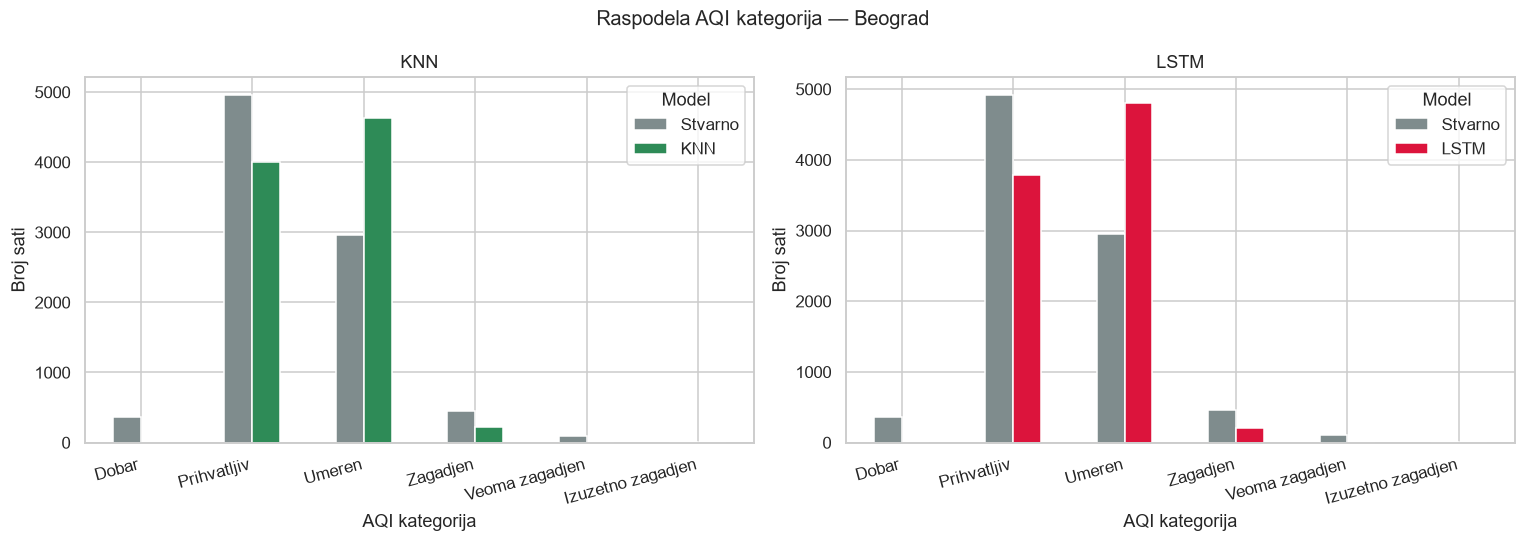

In [12]:
plot_aqi_distribution_per_model(
    [
        (y_test,      y_pred_knn,  'KNN',  'seagreen'),
        (y_test_lstm, y_pred_lstm, 'LSTM', 'crimson'),
    ],
    city=CITY, filename=f'aqi_knn_lstm_{CITY}.png', results_dir=RESULTS,
)

## 10. Zaključak

**LSTM** postiže bolji RMSE (13.18 vs 13.39 μg/m³) i bolji R² od KNN-a, što potvrđuje da eksplicitno modelovanje sekvencijalnosti podataka doprinosi preciznosti. Kroz mehanizam memorijskih kapija, LSTM uspeva da uhvati dugoročne obrasce npr. period grejne sezone koja traje mesecima i postepeno podiže bazni nivo zagađenja.

**KNN** daje iznenađujuće dobre rezultate s obzirom na svoju jednostavnost. Glavna prednost je potpuna transparentnost, predikcija je doslovno prosek K najsličnijih dana iz istorije, što je lako objasniti i verifikovati. Nedostatak je memorijska zahtevnost (čuva ceo trening skup) i sporija predikcija za veliki K.

Oba modela konzistentno prepoznaju AQI kategorije, raspodela predviđenih kategorija je bliska stvarnoj raspodeli na test skupu, što potvrđuje da su modeli upotrebljivi za praktičnu primenu.